## 환경변수 설정

In [ ]:
# open AI key 등록
import os
OPENAI_API_KEY="본인의 OpenAI API 키를 입력하세요"

In [ ]:
# 현재 노트북 커널에 환경변수 등록
os.environ['OPENAI_API_KEY']=OPENAI_API_KEY

In [ ]:
# LangSmith API key등록
LANGSMITH_TRACING="true"
LANGSMITH_ENDPOINT="https://api.smith.langchain.com"
LANGSMITH_API_KEY="본인의 LangSmith API 키를 입력하세요"
LANGSMITH_PROJECT="langchain0422"

# 현재 노트북 커널에 환경변수 등록
os.environ['LANGSMITH_TRACING']=LANGSMITH_TRACING
os.environ['LANGSMITH_ENDPOINT']=LANGSMITH_ENDPOINT
os.environ['LANGSMITH_API_KEY']=LANGSMITH_API_KEY
os.environ['LANGSMITH_PROJECT']=LANGSMITH_PROJECT

### 라이브러리 설치

In [ ]:
!pip install langchain langchain-openai langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.9/515.9 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google

### RunnableWithMessageHistory
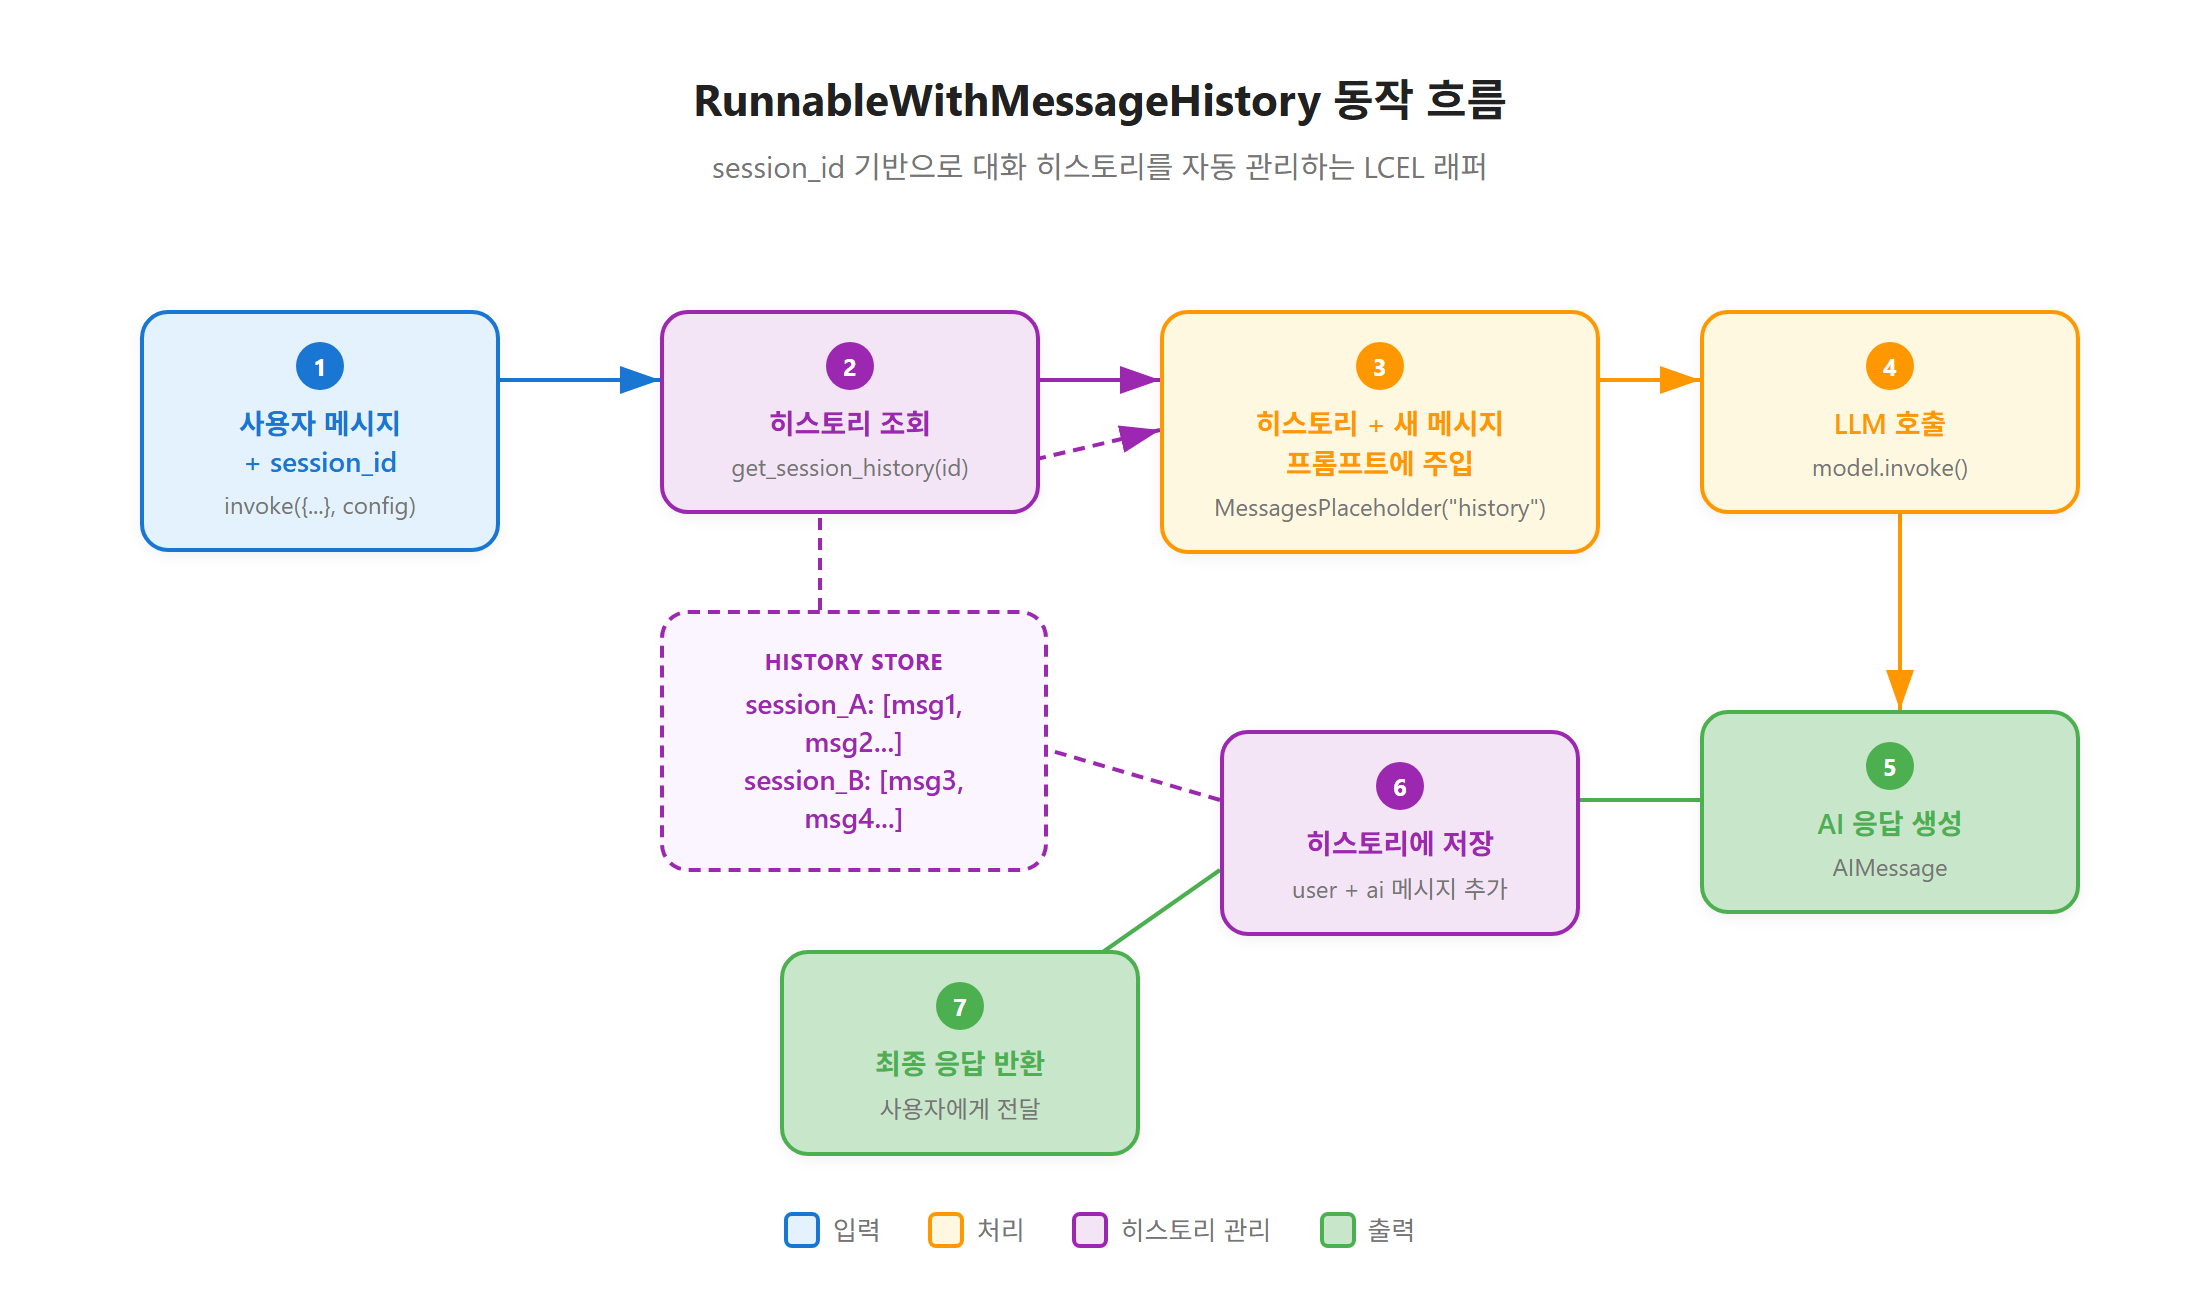

In [ ]:
# session_id 도 함께 받아 관리한다.
# 히스토리조회 , 세션이 없으면 새로 만들어서 관리
# RunnableWithMessageHistory -> 관리자역할
# 대화내역 -> 관리할대상

In [ ]:
from langchain_core.runnables.history import RunnableWithMessageHistory # 대화별 세션관리, 히스토리 관리
from langchain_core.prompts import ChatPromptTemplate # 여러 메세지를 구별해서 구성하는 템플릿
from langchain_core.prompts import MessagesPlaceholder # 과거 메세지를 넣을 공간을 마련하는 도구
from langchain_core.output_parsers import StrOutputParser # 문자열로 파싱하는 도구

# BaseChatMessageHistory 구현체 중에 하나
# 세션별 실제 메세지를 저장하는 공간역할 -> RunnableWithMessageHistory가 이 공간들을 제어
# 나중에 File이나 다양한 DB에 저장하는 ChatMessageHistory 계열을 사용 할 수 있다.
from langchain_community.chat_message_histories import ChatMessageHistory

### 1. LLM 모델 생성
- https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model

In [ ]:
# 다양한 LLM을 쉽게 변경하는 유연한 방식의 모델생성법
from langchain.chat_models import init_chat_model

In [ ]:
llm_4o_mini = init_chat_model("openai:gpt-4o-mini", max_tokens=1024)

### 2. ChatPromptTemplate 만들기

In [ ]:
# 메모리 관리가 되는 챗봇 만든다고 생각

template = ChatPromptTemplate.from_messages([
    ('system', '너는 일상대화용 챗봇이야. 응답할 때는 쉬운단어로 간결하게 대답해줘'),
    MessagesPlaceholder(variable_name="history"), # 도구 사용, 과거 대화기록이 들어갈 공간
    ('human', "{input}") # 사용자의 질문이 들어가는 부분
])

### 3. 대화용 체인 만들기

In [ ]:
my_bot_chain = template | llm_4o_mini | StrOutputParser() # 파서는 생성해서 바로 사용하는 스타일로

### 4. 대화 세션을 관리하는 함수 정의

In [ ]:
# 대화세션 -> 대화주제 구분해서 저장
# ChatMessageHistory() -> 리스트 형태 라고 생각

store = {} # 대화세션을 저장하는 딕셔너리
def get_session_history(session_id) :
  if session_id not in store : # 해당세션이 없는경우
    store[session_id] = ChatMessageHistory() # 대화내역이 저장될 공간을 새롭게 만들고 추가

  return store[session_id] # 해당 세션id에 해당하는 메모리를 반환

### 5. 세션과 히스토리를 관리하는 Runnable 생성

In [ ]:
with_messages_history = RunnableWithMessageHistory(
    my_bot_chain, # 메모리 관리 대상이되는 체인 연결
    get_session_history, # 세션관리 방법을 정의한 함수 연결, 알아서 호출한다.
    history_messages_key= "history", # 메모리를 넣을 입력변수명 지정
    input_messages_key= "input" # 사용자 입력을 넣을 입력변수명 지정
)

In [ ]:
# 실행
msg = input("입력 : ")
with_messages_history.invoke({"input" : msg},
                             config={"configurable" : {"session_id" : "food"}}) # 세션아이디 지정, food 자리에 다른 분야로 넣어서 대화

입력 : 김치찌개 좋다. 김치찌개에 계란후라이


'맛있겠네! 계란후라이 추가하면 더 고소해져! 점심 꼭 맛있게 먹어!'

In [ ]:
# 실행
msg = input("입력 : ")
with_messages_history.invoke({"input" : msg},
                             config={"configurable" : {"session_id" : "movie"}})

입력 : 어떤 배우가 나와?


'"재난의 시대"에는 유명한 배우들이 출연해요. 주인공은 강하늘과 이정은, 그리고 신성록이 주요 역할을 맡고 있습니다. 이 외에도 여러 배우들이 이야기를 이끌어갑니다.'

In [ ]:
store # 'food', 'movie' 각 세션아이디로 대화 내용이 누적되어있는것 확인
# 앞에서는 리스트형태로 추가해줬던것을 RunnableWithMessageHistory를 사용해 누적

{'food': InMemoryChatMessageHistory(messages=[HumanMessage(content='오늘 점심메뉴 추천해줘', additional_kwargs={}, response_metadata={}), AIMessage(content='비빔밥 어때? 건강하고 맛있어!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='비빕밤 말고 다른걸로 추천해봐', additional_kwargs={}, response_metadata={}), AIMessage(content='그럼 김치찌개는 어때? 따뜻하고 든든해!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='김치찌개 좋다. 김치찌개에 계란후라이', additional_kwargs={}, response_metadata={}), AIMessage(content='맛있겠네! 계란후라이 추가하면 더 고소해져! 점심 꼭 맛있게 먹어!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]),
 'movie': InMemoryChatMessageHistory(messages=[HumanMessage(content='지금 흥행하는 한국영화 1위 뭐야', additional_kwargs={}, response_metadata={}), AIMessage(content='현재 흥행하는 한국 영화 1위는 "재난의 시대"입니다. 하지만 영화 정보는 자주 변하니, 최신 소식을 확인해보는 게 좋아!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=

### 6. UI붙이기

In [ ]:
!pip install gradio

In [ ]:
# 응답을 처리하는 알고리즘의 사용자정의함수
def chat_response(message, history):
  ai_res = with_messages_history.invoke({"input" : message},
                                 config={"configurable" : {"session_id" : "movie"}})

  return ai_res

In [ ]:
import gradio as gr

gr.ChatInterface(
    fn=chat_response,
).launch()

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45a0db86289c3b6f6a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
